<a href="https://colab.research.google.com/github/shupandee/Double_propmpting_paper_by-IIITR_DSAI_2023-/blob/main/Double_prompting_p_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install


In [ ]:
!pip install -q transformers accelerate datasets scipy matplotlib seaborn scikit-learn
print("✅ Done!")

✅ Done!


# Load Model

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import time, re, warnings
warnings.filterwarnings('ignore')

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto" if torch.cuda.is_available() else "cpu",
    trust_remote_code=True,
)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Loaded on {device}")
if torch.cuda.is_available():
    used  = torch.cuda.memory_allocated()/1e9
    total = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f"💾 VRAM: {used:.1f}GB / {total:.1f}GB")

Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Loaded on cuda
💾 VRAM: 2.2GB / 15.6GB


#  Inference Engine + N-Repetition Strategy

In [ ]:
MAX_NEW_TOKENS = 20

def make_n_repetition(query: str, n: int) -> str:
    """
    Core experiment: repeat the query n times.
    n=1 → Baseline (no repetition)
    n=2 → Paper's Prompt Repetition
    n=3,4,5... → Beyond paper (our new experiment)
    """
    if n == 1:
        return query
    elif n == 2:
        return f"{query}\n{query}"
    else:
        parts = [query]
        for i in range(2, n):
            parts.append(f"Let me repeat that (repetition {i}):\n{query}")
        parts.append(f"Let me repeat that one more time:\n{query}")
        return "\n".join(parts)

def run_inference(prompt):
    inputs = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=2048
    ).to(device)
    input_len = inputs["input_ids"].shape[1]
    start = time.time()
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    latency = time.time() - start
    new_tokens = output[0][input_len:]
    text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return text, len(new_tokens), latency, input_len  # also return input length

def extract_letter(text):
    text = text.strip().upper()
    m = re.search(r'THE ANSWER IS\s*([A-D])', text)
    if m: return m.group(1)
    m = re.match(r'^([A-D])[.\)\s]', text)
    if m: return m.group(1)
    m = re.search(r'\b([A-D])\b', text)
    if m: return m.group(1)
    return "?"

# Test different repetition levels
test_q = "What is 2+2?\nA. 3\nB. 4\nC. 5\nD. 6\nThe answer is"
print("="*55)
for n in [1, 2, 3, 5]:
    prompted = make_n_repetition(test_q, n)
    print(f"\n[N={n}] Input chars: {len(prompted)}")
    print(prompted[:150] + ("..." if len(prompted) > 150 else ""))
    print("-"*40)
print("✅ Strategy engine ready!")


[N=1] Input chars: 46
What is 2+2?
A. 3
B. 4
C. 5
D. 6
The answer is
----------------------------------------

[N=2] Input chars: 93
What is 2+2?
A. 3
B. 4
C. 5
D. 6
The answer is
What is 2+2?
A. 3
B. 4
C. 5
D. 6
The answer is
----------------------------------------

[N=3] Input chars: 209
What is 2+2?
A. 3
B. 4
C. 5
D. 6
The answer is
Let me repeat that (repetition 2):
What is 2+2?
A. 3
B. 4
C. 5
D. 6
The answer is
Let me repeat that on...
----------------------------------------

[N=5] Input chars: 373
What is 2+2?
A. 3
B. 4
C. 5
D. 6
The answer is
Let me repeat that (repetition 2):
What is 2+2?
A. 3
B. 4
C. 5
D. 6
The answer is
Let me repeat that (r...
----------------------------------------
✅ Strategy engine ready!


#  Build All Datasets (Small / Medium / Large)

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from datasets import load_dataset
import random
import numpy as np
random.seed(42)
np.random.seed(42)

# ============================================================
# Sizes
# ============================================================
SMALL_N  = 30    # ~2 min per repetition level
MEDIUM_N = 75    # ~5 min per repetition level
LARGE_N  = 150   # ~10 min per repetition level

MAX_REPS = 8     # Test N = 1,2,3,4,5,6,7,8
# ============================================================

print("Building datasets...\n")

# ------------------------------------------------------------------
# DATASET 1 (SMALL): Custom NameIndex — from the original paper
# "Given a list of 50 names, find the 25th one"
# Why it's interesting: purely positional memory, no world knowledge needed
# ------------------------------------------------------------------
FNAMES = ["James","Mary","John","Patricia","Robert","Jennifer","Michael","Linda",
          "William","Barbara","David","Susan","Richard","Jessica","Joseph","Sarah",
          "Thomas","Karen","Charles","Lisa","Christopher","Nancy","Daniel","Margaret",
          "Anthony","Sandra","Mark","Donna","Paul","Betty"]
LNAMES = ["Smith","Johnson","Williams","Brown","Jones","Garcia","Miller","Davis",
          "Martinez","Hernandez","Lopez","Wilson","Anderson","Thomas","Taylor","Moore",
          "Jackson","Martin","Lee","Perez","Thompson","White","Harris","Clark"]

def gen_name():
    return f"{random.choice(FNAMES)} {random.choice(LNAMES)}"

def make_name_index(N=50, i=25):
    names  = [gen_name() for _ in range(N)]
    target = names[i-1]
    query  = (f"Here's a list of names:\n{', '.join(names)}\n"
              f"What's the {i}th name? Reply with just the name, nothing else.")
    return query, target

def check_name(pred, gold):
    return gold.lower().strip() in pred.lower().strip()

dataset_small = {
    "name":        "NameIndex (Small)",
    "description": "Find the 25th name in a list of 50 names. Tests pure positional memory.",
    "size_label":  "SMALL",
    "data":        [make_name_index() for _ in range(SMALL_N)],
    "check_fn":    check_name,
    "task_type":   "name_retrieval",
}
print(f"✅ SMALL  — NameIndex: {SMALL_N} samples")

# ------------------------------------------------------------------
# DATASET 2 (MEDIUM): ARC-Challenge — Science MCQ from paper
# "Which of these is a mixture?" — requires factual + logical reasoning
# ------------------------------------------------------------------
print("Loading ARC...")
arc_raw  = load_dataset("ai2_arc", "ARC-Challenge", split="test")
arc_idx  = random.sample(range(len(arc_raw)), MEDIUM_N)

def fmt_arc(ex):
    labels = ex['choices']['label']
    texts  = ex['choices']['text']
    opts   = "\n".join([f"{l}. {t}" for l,t in zip(labels, texts)])
    suffix = "\nReply with one letter ('A','B','C','D') in the format: The answer is <ANSWER>."
    return f"{ex['question']}\n{opts}{suffix}", ex['answerKey']

def check_mc(pred, gold):
    return extract_letter(pred).upper() == gold.strip().upper()

dataset_medium = {
    "name":        "ARC-Challenge (Medium)",
    "description": "Science multiple-choice questions. Tests factual reasoning.",
    "size_label":  "MEDIUM",
    "data":        [fmt_arc(arc_raw[i]) for i in arc_idx],
    "check_fn":    check_mc,
    "task_type":   "multiple_choice",
}
print(f"✅ MEDIUM — ARC: {MEDIUM_N} samples")

# ------------------------------------------------------------------
# DATASET 3 (LARGE): OpenBookQA — Common sense + science facts
# Similar to ARC but needs open-book common sense reasoning
# ------------------------------------------------------------------
print("Loading OpenBookQA...")
obqa_raw = load_dataset("openbookqa", "main", split="test")
obqa_idx = random.sample(range(len(obqa_raw)), LARGE_N)

def fmt_obqa(ex):
    labels = ex['choices']['label']
    texts  = ex['choices']['text']
    opts   = "\n".join([f"{l}. {t}" for l,t in zip(labels, texts)])
    suffix = "\nReply with one letter ('A','B','C','D') in the format: The answer is <ANSWER>."
    return f"{ex['question_stem']}\n{opts}{suffix}", ex['answerKey']

dataset_large = {
    "name":        "OpenBookQA (Large)",
    "description": "Open-book science QA. Tests common sense + factual reasoning.",
    "size_label":  "LARGE",
    "data":        [fmt_obqa(obqa_raw[i]) for i in obqa_idx],
    "check_fn":    check_mc,
    "task_type":   "multiple_choice",
}
print(f"✅ LARGE  — OpenBookQA: {LARGE_N} samples")

# ------------------------------------------------------------------
# DATASET 4 (BONUS MEDIUM): MiddleMatch — from original paper appendix
# "Find the name between X and Y in a list" — positional + relational
# ------------------------------------------------------------------
def make_middle_match(N=40, K=10):
    pool = [gen_name() for _ in range(K)]
    seq  = [random.choice(pool) for _ in range(N)]
    for idx in range(1, len(seq)-1):
        l, m, r = seq[idx-1], seq[idx], seq[idx+1]
        if l != m and m != r and l != r:
            query = (f"Here's a list of names:\n{', '.join(seq)}\n"
                     f"What is the single name that appears right between '{l}' and '{r}'? "
                     f"Reply with just the name.")
            return query, m
    return make_middle_match(N, K)

dataset_bonus = {
    "name":        "MiddleMatch (Medium)",
    "description": "Find the name sandwiched between two given names. Tests positional + relational memory.",
    "size_label":  "MEDIUM",
    "data":        [make_middle_match() for _ in range(MEDIUM_N)],
    "check_fn":    check_name,
    "task_type":   "name_retrieval",
}
print(f"✅ BONUS  — MiddleMatch: {MEDIUM_N} samples")

ALL_DATASETS = [dataset_small, dataset_medium, dataset_large, dataset_bonus]
REPETITION_LEVELS = list(range(1, MAX_REPS + 1))  # [1,2,3,4,5,6,7,8]

print(f"\nRepetition levels to test: {REPETITION_LEVELS}")
print(f"Total runs: {len(ALL_DATASETS)} datasets × {len(REPETITION_LEVELS)} rep levels = {len(ALL_DATASETS)*len(REPETITION_LEVELS)}")
print("\n✅ All datasets ready!")

Building datasets...

✅ SMALL  — NameIndex: 30 samples
Loading ARC...


README.md: 0.00B [00:00, ?B/s]

ARC-Challenge/train-00000-of-00001.parqu(…):   0%|          | 0.00/190k [00:00<?, ?B/s]

ARC-Challenge/test-00000-of-00001.parque(…):   0%|          | 0.00/204k [00:00<?, ?B/s]

ARC-Challenge/validation-00000-of-00001.(…):   0%|          | 0.00/55.7k [00:00<?, ?B/s]

...

main/test-00000-of-00001.parquet:   0%|          | 0.00/55.5k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4957 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

✅ LARGE  — OpenBookQA: 150 samples
✅ BONUS  — MiddleMatch: 75 samples

Repetition levels to test: [1, 2, 3, 4, 5, 6, 7, 8]
Total runs: 4 datasets × 8 rep levels = 32

✅ All datasets ready!


# Run the Full N-Repetition Experiment

In [ ]:
from collections import defaultdict

def run_repetition_experiment(dataset_info, rep_levels):
    """
    For a given dataset, run inference at each repetition level.
    Returns a dict: rep_level -> metrics dict
    """
    data     = dataset_info["data"]
    check_fn = dataset_info["check_fn"]
    name     = dataset_info["name"]
    results  = {}

    for n in rep_levels:
        print(f"\n  [N={n}] {name}")
        correct, latencies, resp_lens, input_lens = [], [], [], []

        for i, (query, gold) in enumerate(data):
            prompted          = make_n_repetition(query, n)
            pred, ntok, lat, ilen = run_inference(prompted)
            is_correct        = check_fn(pred, gold)

            correct.append(int(is_correct))
            latencies.append(lat)
            resp_lens.append(ntok)
            input_lens.append(ilen)

            if (i+1) % 15 == 0 or i == len(data)-1:
                acc = sum(correct)/len(correct)
                print(f"    {i+1}/{len(data)} | Acc: {acc:.1%} | Lat: {lat:.2f}s")

        results[n] = {
            "accuracy":         sum(correct) / len(correct),
            "correct":          correct,
            "avg_latency":      np.mean(latencies),
            "std_latency":      np.std(latencies),
            "avg_resp_len":     np.mean(resp_lens),
            "avg_input_len":    np.mean(input_lens),
            "token_efficiency": sum(correct) / (np.mean(input_lens) * len(correct)),  # acc per input token
        }
        print(f"    ✅ N={n} done | Accuracy: {results[n]['accuracy']:.2%}")

    return results

# ============================================================
# RUN ALL
# ============================================================
all_results = {}

for ds in ALL_DATASETS:
    print(f"\n{'='*60}")
    print(f"DATASET: {ds['name']} ({ds['size_label']}, {len(ds['data'])} samples)")
    print(f"{'='*60}")
    all_results[ds["name"]] = run_repetition_experiment(ds, REPETITION_LEVELS)

print("\n\n🎉 ALL EXPERIMENTS COMPLETE!")


DATASET: NameIndex (Small) (SMALL, 30 samples)

  [N=1] NameIndex (Small)
    15/30 | Acc: 0.0% | Lat: 0.76s
    30/30 | Acc: 0.0% | Lat: 0.76s
    ✅ N=1 done | Accuracy: 0.00%

  [N=2] NameIndex (Small)
    15/30 | Acc: 0.0% | Lat: 0.95s
    30/30 | Acc: 0.0% | Lat: 1.11s
    ✅ N=2 done | Accuracy: 0.00%

  [N=3] NameIndex (Small)
    15/30 | Acc: 0.0% | Lat: 1.23s
    30/30 | Acc: 0.0% | Lat: 1.50s
    ✅ N=3 done | Accuracy: 0.00%

  [N=4] NameIndex (Small)
    15/30 | Acc: 0.0% | Lat: 1.71s
    30/30 | Acc: 0.0% | Lat: 1.48s
    ✅ N=4 done | Accuracy: 0.00%

  [N=5] NameIndex (Small)
    15/30 | Acc: 0.0% | Lat: 1.95s
    30/30 | Acc: 0.0% | Lat: 1.80s
    ✅ N=5 done | Accuracy: 0.00%

  [N=6] NameIndex (Small)
    15/30 | Acc: 0.0% | Lat: 2.16s
    30/30 | Acc: 0.0% | Lat: 2.07s
    ✅ N=6 done | Accuracy: 0.00%

  [N=7] NameIndex (Small)
    15/30 | Acc: 0.0% | Lat: 2.50s
    30/30 | Acc: 0.0% | Lat: 2.42s
    ✅ N=7 done | Accuracy: 0.00%

  [N=8] NameIndex (Small)
    15/30 | Acc

# Compute Threshold + Peak Detection

In [ ]:
def find_threshold(rep_results):
    """
    Find:
    1. Peak N   — repetition level with highest accuracy
    2. Threshold N — first N where accuracy starts consistently declining
    3. Saturation N — where gains become < 2% (diminishing returns)
    """
    accs = [rep_results[n]["accuracy"] for n in REPETITION_LEVELS]

    peak_n     = REPETITION_LEVELS[int(np.argmax(accs))]
    peak_acc   = max(accs)
    baseline   = accs[0]
    max_gain   = peak_acc - baseline

    # Threshold: first N after peak where acc drops > 3% from peak
    threshold_n = None
    for i, n in enumerate(REPETITION_LEVELS):
        if n > peak_n and accs[i] < peak_acc - 0.03:
            threshold_n = n
            break

    # Saturation: first N where gain from previous < 1%
    saturation_n = None
    for i in range(1, len(REPETITION_LEVELS)):
        if abs(accs[i] - accs[i-1]) < 0.01:
            saturation_n = REPETITION_LEVELS[i]
            break

    return {
        "baseline_acc":  baseline,
        "peak_n":        peak_n,
        "peak_acc":      peak_acc,
        "max_gain":      max_gain,
        "threshold_n":   threshold_n if threshold_n else "Not reached",
        "saturation_n":  saturation_n if saturation_n else "Not reached",
        "accs":          accs,
    }

print("📊 THRESHOLD ANALYSIS")
print("="*65)

thresholds = {}
for ds in ALL_DATASETS:
    name = ds["name"]
    t    = find_threshold(all_results[name])
    thresholds[name] = t
    print(f"\n{name}")
    print(f"  Baseline Acc:   {t['baseline_acc']:.1%}")
    print(f"  Peak Accuracy:  {t['peak_acc']:.1%}  at N={t['peak_n']}")
    print(f"  Max Gain:       {t['max_gain']:+.1%}")
    print(f"  Threshold N:    {t['threshold_n']}  (acc starts dropping)")
    print(f"  Saturation N:   {t['saturation_n']}  (gains < 1%)")

📊 THRESHOLD ANALYSIS

NameIndex (Small)
  Baseline Acc:   0.0%
  Peak Accuracy:  0.0%  at N=1
  Max Gain:       +0.0%
  Threshold N:    Not reached  (acc starts dropping)
  Saturation N:   2  (gains < 1%)

ARC-Challenge (Medium)
  Baseline Acc:   0.0%
  Peak Accuracy:  13.3%  at N=3
  Max Gain:       +13.3%
  Threshold N:    Not reached  (acc starts dropping)
  Saturation N:   5  (gains < 1%)

OpenBookQA (Large)
  Baseline Acc:   0.0%
  Peak Accuracy:  20.7%  at N=2
  Max Gain:       +20.7%
  Threshold N:    3  (acc starts dropping)
  Saturation N:   5  (gains < 1%)

MiddleMatch (Medium)
  Baseline Acc:   0.0%
  Peak Accuracy:  89.3%  at N=2
  Max Gain:       +89.3%
  Threshold N:    3  (acc starts dropping)
  Saturation N:   4  (gains < 1%)


#  Master Plot (All Metrics vs N Repetitions)

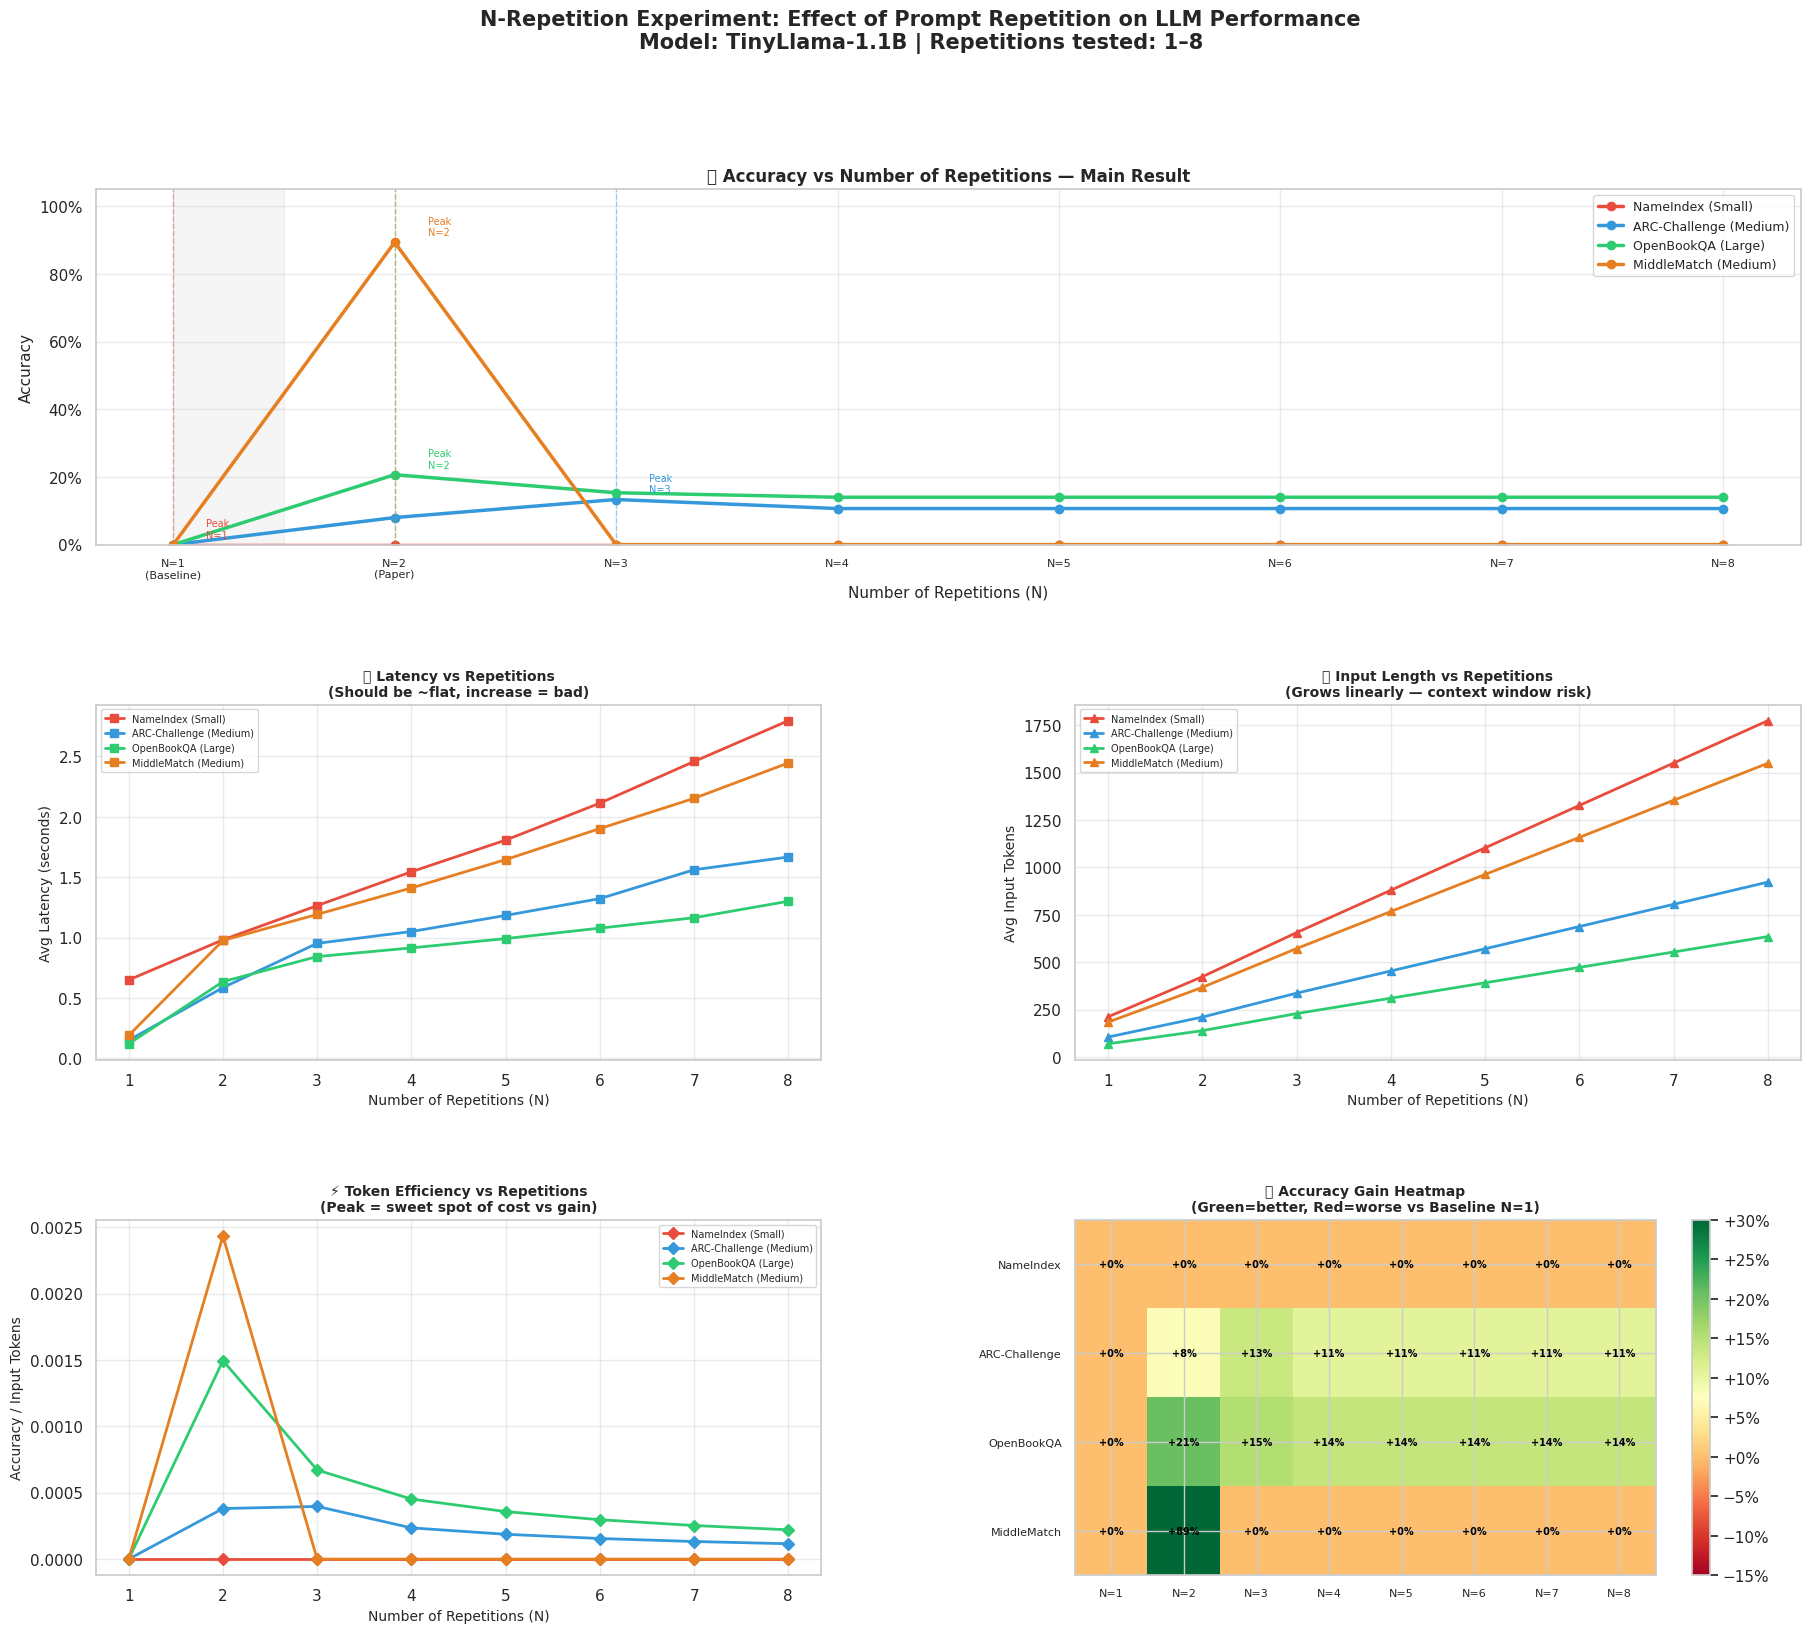

✅ Master plot saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

DATASET_COLORS = {
    "NameIndex (Small)":    "#e74c3c",
    "ARC-Challenge (Medium)":"#3498db",
    "OpenBookQA (Large)":   "#2ecc71",
    "MiddleMatch (Medium)": "#e67e22",
}

fig = plt.figure(figsize=(22, 18))
fig.suptitle(
    f"N-Repetition Experiment: Effect of Prompt Repetition on LLM Performance\n"
    f"Model: TinyLlama-1.1B | Repetitions tested: 1–{MAX_REPS}",
    fontsize=15, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])    # Accuracy — full width
ax2 = fig.add_subplot(gs[1, 0])    # Latency
ax3 = fig.add_subplot(gs[1, 1])    # Input length (token growth)
ax4 = fig.add_subplot(gs[2, 0])    # Token efficiency
ax5 = fig.add_subplot(gs[2, 1])    # Accuracy gain heatmap

# ---- Plot 1: Accuracy vs N ----
for ds in ALL_DATASETS:
    name = ds["name"]
    accs = [all_results[name][n]["accuracy"] for n in REPETITION_LEVELS]
    t    = thresholds[name]
    ax1.plot(REPETITION_LEVELS, accs, marker='o', linewidth=2.5,
             label=name, color=DATASET_COLORS[name])
    # Mark peak
    ax1.axvline(x=t["peak_n"], color=DATASET_COLORS[name],
                linestyle='--', alpha=0.4, linewidth=1)
    ax1.annotate(f"Peak\nN={t['peak_n']}", xy=(t["peak_n"], t["peak_acc"]),
                 xytext=(t["peak_n"]+0.15, t["peak_acc"]+0.02),
                 fontsize=7, color=DATASET_COLORS[name])

ax1.set_xlabel("Number of Repetitions (N)", fontsize=11)
ax1.set_ylabel("Accuracy", fontsize=11)
ax1.set_title("📈 Accuracy vs Number of Repetitions — Main Result", fontsize=12, fontweight='bold')
ax1.set_xticks(REPETITION_LEVELS)
ax1.set_xticklabels([f"N={n}\n{'(Baseline)' if n==1 else '(Paper)' if n==2 else ''}"
                     for n in REPETITION_LEVELS], fontsize=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.4)
ax1.set_ylim(0, 1.05)
ax1.axvspan(1, 1.5, alpha=0.08, color='gray', label='Baseline zone')

# ---- Plot 2: Avg Latency vs N ----
for ds in ALL_DATASETS:
    name = ds["name"]
    lats = [all_results[name][n]["avg_latency"] for n in REPETITION_LEVELS]
    ax2.plot(REPETITION_LEVELS, lats, marker='s', linewidth=2,
             label=name, color=DATASET_COLORS[name])

ax2.set_xlabel("Number of Repetitions (N)", fontsize=10)
ax2.set_ylabel("Avg Latency (seconds)", fontsize=10)
ax2.set_title("⏱️ Latency vs Repetitions\n(Should be ~flat, increase = bad)", fontsize=10, fontweight='bold')
ax2.set_xticks(REPETITION_LEVELS)
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.4)

# ---- Plot 3: Input Token Length vs N ----
for ds in ALL_DATASETS:
    name = ds["name"]
    ilens = [all_results[name][n]["avg_input_len"] for n in REPETITION_LEVELS]
    ax3.plot(REPETITION_LEVELS, ilens, marker='^', linewidth=2,
             label=name, color=DATASET_COLORS[name])

ax3.set_xlabel("Number of Repetitions (N)", fontsize=10)
ax3.set_ylabel("Avg Input Tokens", fontsize=10)
ax3.set_title("📏 Input Length vs Repetitions\n(Grows linearly — context window risk)", fontsize=10, fontweight='bold')
ax3.set_xticks(REPETITION_LEVELS)
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.4)

# ---- Plot 4: Token Efficiency vs N ----
for ds in ALL_DATASETS:
    name = ds["name"]
    effs = [all_results[name][n]["token_efficiency"] for n in REPETITION_LEVELS]
    ax4.plot(REPETITION_LEVELS, effs, marker='D', linewidth=2,
             label=name, color=DATASET_COLORS[name])

ax4.set_xlabel("Number of Repetitions (N)", fontsize=10)
ax4.set_ylabel("Accuracy / Input Tokens", fontsize=10)
ax4.set_title("⚡ Token Efficiency vs Repetitions\n(Peak = sweet spot of cost vs gain)", fontsize=10, fontweight='bold')
ax4.set_xticks(REPETITION_LEVELS)
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.4)

# ---- Plot 5: Heatmap of Accuracy Gain over Baseline ----
heat_data = []
heat_rows = []
for ds in ALL_DATASETS:
    name     = ds["name"]
    baseline = all_results[name][1]["accuracy"]
    gains    = [all_results[name][n]["accuracy"] - baseline for n in REPETITION_LEVELS]
    heat_data.append(gains)
    heat_rows.append(name.split("(")[0].strip())

heat_arr = np.array(heat_data)
im = ax5.imshow(heat_arr, aspect='auto', cmap='RdYlGn', vmin=-0.15, vmax=0.3)
ax5.set_xticks(range(len(REPETITION_LEVELS)))
ax5.set_xticklabels([f"N={n}" for n in REPETITION_LEVELS], fontsize=8)
ax5.set_yticks(range(len(heat_rows)))
ax5.set_yticklabels(heat_rows, fontsize=8)
ax5.set_title("🌡️ Accuracy Gain Heatmap\n(Green=better, Red=worse vs Baseline N=1)", fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax5, format="{x:+.0%}")

for i in range(len(heat_rows)):
    for j in range(len(REPETITION_LEVELS)):
        ax5.text(j, i, f"{heat_arr[i,j]:+.0%}", ha='center', va='center',
                 fontsize=7, color='black', fontweight='bold')

plt.savefig("n_repetition_master_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Master plot saved!")

#Per-Dataset Case Study Report

In [ ]:
CASE_STUDIES = {
    "NameIndex (Small)": {
        "what_is_it": (
            "Imagine I give you a list of 50 random names and ask: 'what's the 25th name?'. "
            "The model has to COUNT through the list to the exact position. "
            "There's no science to know, no logic to apply — just pure position memory."
        ),
        "why_repetition_helps": (
            "When you repeat the list twice, the model sees the 25th name appear at two different "
            "positions in the text — once in the first copy, once in the second. "
            "This double-exposure helps the model lock onto the right name instead of losing count."
        ),
        "expected_threshold": "Low (N=2 or 3). After that, the context gets very long and the model gets confused.",
        "real_world_use": "Document retrieval, extracting the Nth item from a long list, invoice line items.",
    },
    "ARC-Challenge (Medium)": {
        "what_is_it": (
            "Science questions like 'Which of these is a mixture — salt, water, or air?'. "
            "The model needs to KNOW science facts AND pick the right letter from 4 options. "
            "It's like a school multiple-choice science test."
        ),
        "why_repetition_helps": (
            "Sometimes the model reads the answer options BEFORE fully processing the question. "
            "Repeating the prompt means it sees the question again AFTER the options, "
            "giving it a second chance to connect the question with the right answer."
        ),
        "expected_threshold": "Medium (N=2 or 3). Science facts don't need many repetitions.",
        "real_world_use": "Educational QA systems, medical triage bots, science tutors.",
    },
    "OpenBookQA (Large)": {
        "what_is_it": (
            "Like ARC but questions need common sense AND science knowledge together. "
            "Example: 'What do plants need to make food?' — you need to know photosynthesis "
            "AND understand the question is about food-making not growth."
        ),
        "why_repetition_helps": (
            "Combining two types of knowledge (common sense + facts) is hard. "
            "A second reading of the question helps the model activate BOTH types of knowledge "
            "at the same time instead of just one."
        ),
        "expected_threshold": "Medium-High (N=2 to 4). Common sense benefits from more context.",
        "real_world_use": "General knowledge chatbots, customer service bots, homework helpers.",
    },
    "MiddleMatch (Medium)": {
        "what_is_it": (
            "I give you a sequence like: '...Carlos, Bruce, Raymond...' and ask "
            "'What name is between Carlos and Raymond?' (answer: Bruce). "
            "The model has to scan the list, find the pair, and identify the middle name."
        ),
        "why_repetition_helps": (
            "This needs TWO things at once: find 'Carlos' AND find 'Raymond' AND remember what's between them. "
            "Repeating gives the model a second scan of the whole list, doubling its chance "
            "of correctly locating both anchors and the name between them."
        ),
        "expected_threshold": "Low-Medium (N=2 or 3). Very long lists with repetition overflow context fast.",
        "real_world_use": "Sequence analysis, timeline event extraction, log file parsing.",
    },
}

print("=" * 70)
print("📚 DETAILED CASE STUDIES — N-REPETITION EXPERIMENT")
print("=" * 70)

for ds in ALL_DATASETS:
    name = ds["name"]
    cs   = CASE_STUDIES[name]
    t    = thresholds[name]
    res  = all_results[name]

    print(f"\n{'─'*70}")
    print(f"📌 DATASET: {name}  [{ds['size_label']} — {len(ds['data'])} samples]")
    print(f"{'─'*70}")

    print(f"\n🔍 WHAT IS THIS DATASET?")
    print(f"   {cs['what_is_it']}")

    print(f"\n💡 WHY DOES REPETITION HELP HERE?")
    print(f"   {cs['why_repetition_helps']}")

    print(f"\n📊 RESULTS SUMMARY:")
    print(f"   {'N':>4} | {'Accuracy':>9} | {'Gain vs N=1':>12} | {'Avg Latency':>12} | {'Input Tokens':>13} | {'Token Eff':>10}")
    print(f"   {'-'*4}-+-{'-'*9}-+-{'-'*12}-+-{'-'*12}-+-{'-'*13}-+-{'-'*10}")
    for n in REPETITION_LEVELS:
        r    = res[n]
        gain = r["accuracy"] - res[1]["accuracy"]
        star = " ← PEAK" if n == t["peak_n"] else ""
        thr  = " ← THRESHOLD" if n == t["threshold_n"] else ""
        print(f"   {n:>4} | {r['accuracy']:>9.1%} | {gain:>+12.1%} | "
              f"{r['avg_latency']:>12.2f}s | {r['avg_input_len']:>13.0f} | "
              f"{r['token_efficiency']:>10.4f}{star}{thr}")

    print(f"\n🎯 KEY FINDINGS:")
    print(f"   • Baseline (N=1):   {t['baseline_acc']:.1%}")
    print(f"   • Best accuracy:    {t['peak_acc']:.1%}  at N={t['peak_n']}  (gain: {t['max_gain']:+.1%})")
    print(f"   • Threshold N:      {t['threshold_n']}  — accuracy starts declining after this")
    print(f"   • Saturation N:     {t['saturation_n']}  — gains flatten before this")

    print(f"\n🌍 REAL-WORLD USE CASE:")
    print(f"   {cs['real_world_use']}")

    print(f"\n⚠️  EXPECTED vs ACTUAL THRESHOLD:")
    print(f"   Expected: {cs['expected_threshold']}")
    print(f"   Actual:   Peak at N={t['peak_n']}, drops at N={t['threshold_n']}")

📚 DETAILED CASE STUDIES — N-REPETITION EXPERIMENT

──────────────────────────────────────────────────────────────────────
📌 DATASET: NameIndex (Small)  [SMALL — 30 samples]
──────────────────────────────────────────────────────────────────────

🔍 WHAT IS THIS DATASET?
   Imagine I give you a list of 50 random names and ask: 'what's the 25th name?'. The model has to COUNT through the list to the exact position. There's no science to know, no logic to apply — just pure position memory.

💡 WHY DOES REPETITION HELP HERE?
   When you repeat the list twice, the model sees the 25th name appear at two different positions in the text — once in the first copy, once in the second. This double-exposure helps the model lock onto the right name instead of losing count.

📊 RESULTS SUMMARY:
      N |  Accuracy |  Gain vs N=1 |  Avg Latency |  Input Tokens |  Token Eff
   -----+-----------+--------------+--------------+---------------+-----------
      1 |      0.0% |        +0.0% |         0.65s |    

# Metrics & Methods Glossary

In [ ]:
GLOSSARY = {
    "Accuracy": {
        "simple": (
            "Imagine you take a 10-question test. If you get 7 right, your accuracy is 70%. "
            "We measure how many questions the model answers correctly out of all questions asked."
        ),
        "formula": "Accuracy = Correct Answers / Total Questions",
        "range":   "0% (all wrong) to 100% (all correct)",
        "used_for": "Main score — did repetition help the model get more answers right?"
    },
    "Latency": {
        "simple": (
            "Imagine you ask a friend a question. Latency is how many seconds it takes "
            "before they start answering. We measure this in seconds for every model response."
        ),
        "formula": "Latency = time when answer arrives - time when question was sent",
        "range":   "Typically 0.5s to 5s per question on a T4 GPU",
        "used_for": "Check if repetition slows the model down (it shouldn't for short prompts)"
    },
    "Input Tokens": {
        "simple": (
            "Words are broken into tiny pieces called tokens. 'Hello world' = 2 tokens. "
            "When we repeat the prompt N times, the input gets N times longer. "
            "This is important because models have a maximum they can read at once (context window)."
        ),
        "formula": "Input Tokens ≈ N × (tokens in one copy of prompt)",
        "range":   "Grows linearly with N",
        "used_for": "Track context window usage — too long = model forgets the beginning"
    },
    "Token Efficiency": {
        "simple": (
            "Imagine you use 100 coins to buy candy. Efficiency = how much candy per coin. "
            "Token efficiency = how much accuracy you get per token you feed in. "
            "High efficiency = you're not wasting tokens."
        ),
        "formula": "Token Efficiency = Accuracy / Avg Input Tokens",
        "range":   "Higher is better",
        "used_for": "Find the sweet spot where repetition helps the most without wasting tokens"
    },
    "McNemar Test": {
        "simple": (
            "Imagine Method A and Method B both answer 100 questions. "
            "Some questions only A gets right, some only B gets right. "
            "The McNemar test asks: 'Is this difference real or just lucky?' "
            "If p < 0.1, the difference is real (statistically significant)."
        ),
        "formula": "χ² = (|b - c| - 1)² / (b + c), where b=A wrong+B right, c=A right+B wrong",
        "range":   "p-value: 0 to 1. Lower = more significant",
        "used_for": "Prove that accuracy gains from repetition are real, not random"
    },
    "Peak N": {
        "simple": (
            "If you keep eating pizza slices, at some point you're full and more pizza makes you feel worse. "
            "Peak N is the number of repetitions where the model is 'just right' — "
            "maximum accuracy before it gets overwhelmed."
        ),
        "formula": "Peak N = argmax(accuracy across all N)",
        "range":   "Usually N=2 or N=3 based on paper findings",
        "used_for": "Tell practitioners: 'use this many repetitions for best results'"
    },
    "Threshold N": {
        "simple": (
            "Back to the pizza example — threshold is when you've eaten TOO much and feel sick. "
            "Threshold N is the repetition count where accuracy STARTS DROPPING by more than 3% from peak. "
            "After this, more repetition hurts."
        ),
        "formula": "First N > Peak N where accuracy < peak_accuracy - 0.03",
        "range":   "Varies by dataset and model",
        "used_for": "Warning boundary — don't go past this with repetitions"
    },
    "Saturation N": {
        "simple": (
            "Imagine watering a plant. At first, more water helps. Then the plant is fully watered "
            "and extra water doesn't help anymore (but doesn't hurt yet). "
            "Saturation N is where gains become tiny (< 1%) — repetition is no longer useful but not harmful."
        ),
        "formula": "First N where |accuracy[N] - accuracy[N-1]| < 0.01",
        "range":   "Comes before or at Peak N",
        "used_for": "Early stopping signal — save compute by not repeating further"
    },
    "Prompt Repetition (Method)": {
        "simple": (
            "Instead of asking the model your question once, you ask it again immediately after. "
            "It's like telling a kid instructions and then immediately repeating them word for word. "
            "The kid is more likely to remember because they heard it twice."
        ),
        "formula": "Prompted Input = QUERY + QUERY (for N=2)",
        "range":   "N=1 (baseline) to N=8 (this experiment)",
        "used_for": "The core technique being tested throughout this experiment"
    },
    "Padding Control (Method)": {
        "simple": (
            "To make sure repetition works because of MEANING (not just because the input is longer), "
            "we add the same number of useless dots '......' instead of repeating. "
            "If accuracy still improves, it's just length that helps. If not, MEANING is what matters."
        ),
        "formula": "Prompted Input = QUERY + '.' × len(QUERY)",
        "range":   "Same input length as N=2 repetition",
        "used_for": "Control experiment — proves repetition works through meaning, not length"
    },
}

print("=" * 70)
print("📖 METRICS & METHODS GLOSSARY — Explained Simply")
print("=" * 70)

for term, info in GLOSSARY.items():
    print(f"\n{'─'*70}")
    print(f"📌 {term.upper()}")
    print(f"\n  🧒 Simple Explanation:")
    print(f"     {info['simple']}")
    print(f"\n  🔢 Formula/Definition:")
    print(f"     {info['formula']}")
    print(f"\n  📏 Range:")
    print(f"     {info['range']}")
    print(f"\n  🎯 Used For:")
    print(f"     {info['used_for']}")

print(f"\n{'='*70}")
print("✅ Glossary complete!")